#### Question Statement

## Q.1 Fragment length frequency
A) You are given a file with each line indicating where a DNA fragment has mapped on the chromosome. Your goal is to count individual fragment lengths, and then normalize it by the total count of all fragment lengths. Once you have the normalized count, you will plot that using plotting packages in Python. X-axis will be fragment length (unit: base pairs) and Y-axis will be labelled "Narmalized Frequency [A.U.]". Fragment length can simply be calculated by subtracting 2nd column from the 3rd.

B) Rescaling
Often, you will received two sets of data with differnt emperical distribution. The goal is to rescale one (query) to the other (reference). In this part, you will write codes to achieve this. You are given a reference distribution (reference.hist) and a query bed file (query.bed.gz). You have to rescale (subsample the data) so that when you draw the normalized frequency, it should almost match the reference.

Importing necessary libraries

In [1]:
import gzip                     
import numpy as np                
import matplotlib.pyplot as plt   
from collections import Counter   

Calculate normalized frequency of fragment lengths

In [ ]:
segment_lengths = []  # for each fragment’s length here

with gzip.open('data/fragment/query.bed.gz', 'rt') as bed_file:
    for line in bed_file:
        # skip over commentary lines and blanks
        if line.startswith('#') or not line.strip():
            continue
        cols = line.strip().split()
        segment_lengths.append(int(cols[2]) - int(cols[1]))
length_counts = Counter(segment_lengths)
total_counts = sum(length_counts.values())
unique_lengths = np.array(list(length_counts.keys()))
frequencies = np.array(list(length_counts.values()))
normalized_frequencies = frequencies / total_counts

Plotting sorted normalized DNA fragment length distribution

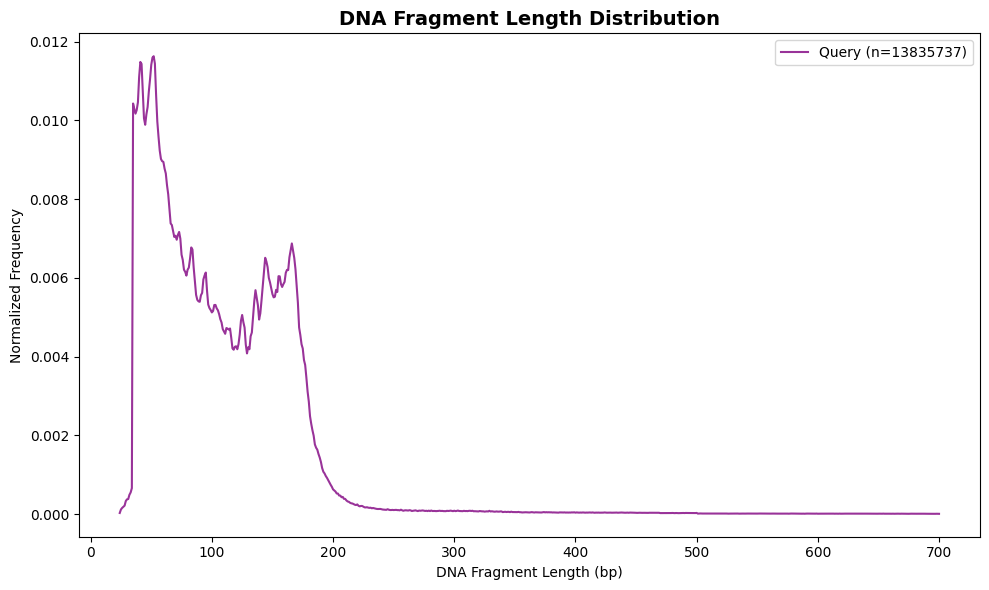

In [3]:
sort_idx = np.argsort(unique_lengths)
lengths_sorted = unique_lengths[sort_idx]
freqs_sorted = normalized_frequencies[sort_idx]

# plotting the distribution curve
plt.figure(figsize=(10, 6))
plt.plot(
    lengths_sorted,
    freqs_sorted,
    linestyle='-',
    alpha=0.8,
    color='purple',
    label=f'Query (n={total_counts})'
)
plt.legend()
plt.xlabel('DNA Fragment Length (bp)')
plt.ylabel('Normalized Frequency')
plt.title('DNA Fragment Length Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Compare rescaled sample distribution to reference distribution

In [4]:
reference_lengths = []
reference_frequencies = []

with open('data/fragment/reference.hist', 'r') as ref_file:
    for line in ref_file:
        if not line.strip():
            continue

        size_str, freq_str = line.split()
        reference_lengths.append(int(float(size_str)))
        reference_frequencies.append(float(freq_str))

reference_lengths = np.array(reference_lengths)
reference_frequencies = np.array(reference_frequencies)


subsample_count_target = int(0.3 * len(segment_lengths))
scaled_counts = (reference_frequencies / reference_frequencies.sum()) * subsample_count_target
scaled_counts = scaled_counts.astype(int)
observed_length_counts = Counter(segment_lengths)

resampled_lengths = []
for length, target in zip(reference_lengths, scaled_counts):
    available = observed_length_counts.get(length, 0)
    if available <= 0:
        continue
    take = min(available, target)
    resampled_lengths.extend([length] * take)
    observed_length_counts[length] -= take
resampled_length_counts = Counter(resampled_lengths)
resampled_lengths_unique = np.array(list(resampled_length_counts.keys()))
resampled_counts = np.array(list(resampled_length_counts.values()))
resampled_frequencies = resampled_counts / resampled_counts.sum()

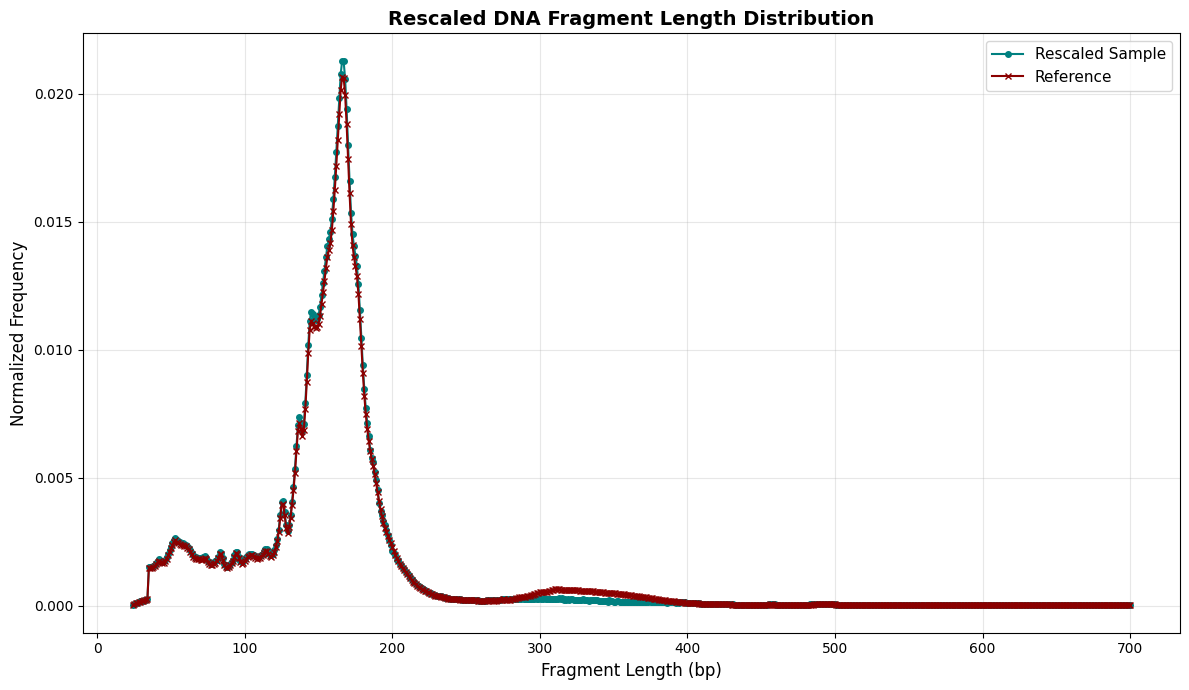

In [5]:
plt.figure(figsize=(12, 7))
plt.plot(
    resampled_lengths_unique,
    resampled_frequencies,
    'o-',
    label='Rescaled Sample',
    markersize=4,
    color='teal'
)
plt.plot(
    reference_lengths,
    reference_frequencies / reference_frequencies.sum(),
    'x-',
    label='Reference',
    markersize=4,
    color='darkred'
)
plt.xlabel('Fragment Length (bp)', fontsize=12)
plt.ylabel('Normalized Frequency', fontsize=12)
plt.title('Rescaled DNA Fragment Length Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Compare original, reference, and rescaled fragment length distributions

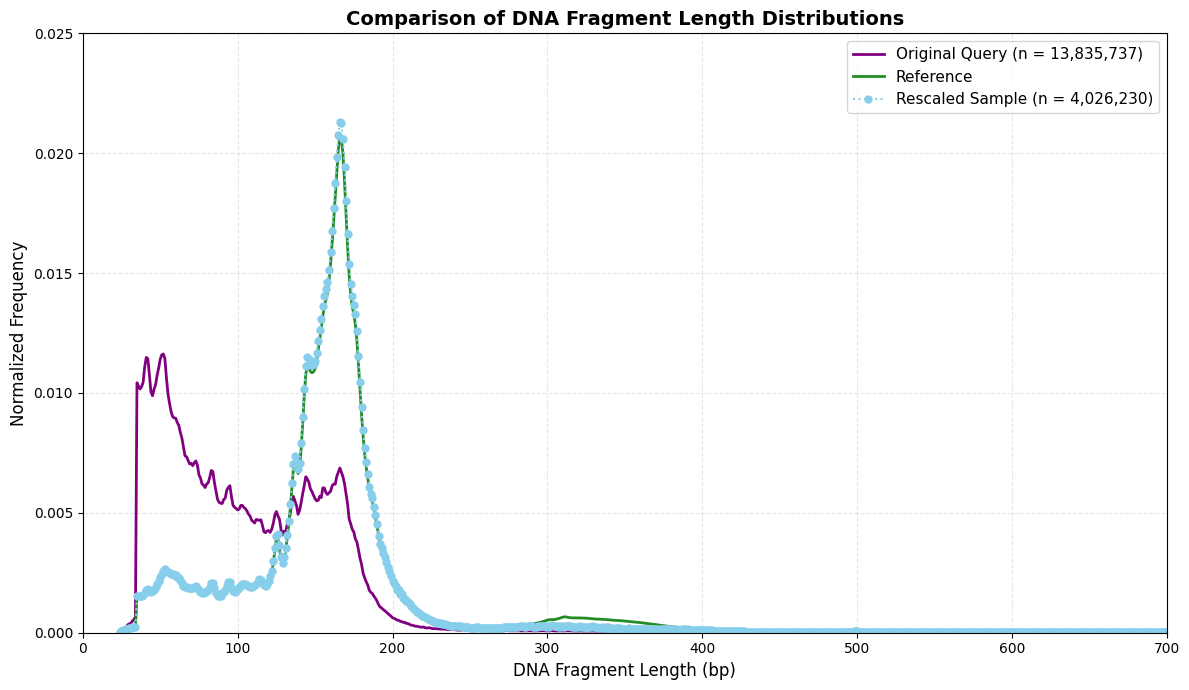

In [6]:
plt.figure(figsize=(12, 7))

# plot the original query distribution
query_idx = np.argsort(unique_lengths)
plt.plot(
    unique_lengths[query_idx],
    normalized_frequencies[query_idx],
    color='purple',
    linewidth=2,
    label=f'Original Query (n = {len(segment_lengths):,})'
)

# overlay the reference profile
ref_idx = np.argsort(reference_lengths)
plt.plot(
    reference_lengths[ref_idx],
    reference_frequencies[ref_idx] / reference_frequencies.sum(),
    color='forestgreen',
    linewidth=2,
    label='Reference'
)

# add the rescaled sample curve
resampled_idx = np.argsort(resampled_lengths_unique)
plt.plot(
    resampled_lengths_unique[resampled_idx],
    resampled_frequencies[resampled_idx],
    marker='o',
    linestyle=':',
    linewidth=1.5,
    markersize=5,
    color='skyblue',
    label=f'Rescaled Sample (n = {len(resampled_lengths):,})'
)

plt.xlabel('DNA Fragment Length (bp)', fontsize=12)
plt.ylabel('Normalized Frequency', fontsize=12)
plt.title('Comparison of DNA Fragment Length Distributions', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, 700)
plt.ylim(0, 0.025)
plt.tight_layout()
plt.show()
